# Course 3 · Week 3 — Solution: Q-learning on Mars Rover

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1-D Mars rover. 6 states in a row.
#  state:  0       1     2     3     4       5
#  reward: 100     0     0     0     0      40   (only at terminal states)
#  type:   TERM    --    --    --    --    TERM
N_STATES  = 6
N_ACTIONS = 2          # 0 = move left, 1 = move right
TERMINAL  = {0, 5}
REWARDS   = {0: 100.0, 5: 40.0}

def step(s, a):
    """Take action a from state s. Returns (s_next, reward, done)."""
    if s in TERMINAL:
        return s, 0.0, True
    s_next = max(0, s - 1) if a == 0 else min(N_STATES - 1, s + 1)
    return s_next, REWARDS.get(s_next, 0.0), s_next in TERMINAL

print(f"States: 0–{N_STATES-1} | Terminals at {sorted(TERMINAL)} with rewards {REWARDS}")
print(f"Quick test: step(2, 1) = {step(2, 1)}   expect (3, 0.0, False)")
print(f"Quick test: step(4, 1) = {step(4, 1)}   expect (5, 40.0, True)")


States: 0–5 | Terminals at [0, 5] with rewards {0: 100.0, 5: 40.0}
Quick test: step(2, 1) = (3, 0.0, False)   expect (3, 0.0, False)
Quick test: step(4, 1) = (5, 40.0, True)   expect (5, 40.0, True)


## Quick recap

**Q-value** Q(s, a) = the expected total reward from taking action `a` in state `s` and acting optimally afterward.

**Bellman equation:**

$$Q(s, a) = r(s') + \gamma \max_{a'} Q(s', a')$$

In words: the value of taking action `a` is the immediate reward plus a discounted look at the best you can do *next*. The discount factor `γ` (gamma) controls patience — `γ = 0` is "live for today", `γ = 1` is "no time preference". Most problems use 0.5 to 0.99.

**Q-learning update** (one TD step):

$$Q(s, a) \leftarrow Q(s, a) + \alpha \bigl[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \bigr]$$

It nudges the current Q-estimate toward the target (reward + discounted future value). With enough exploration and enough episodes, this converges to the true optimal Q.

**Epsilon-greedy:** with probability `epsilon` pick a random action (explore); otherwise pick `argmax Q(s, *)` (exploit). Without exploration the agent might get stuck in a sub-optimal habit. With *too much* exploration it never settles. Standard trick: start with high epsilon and decay over time.


**Implementation notes**\n\n`epsilon_greedy` is one branch: random or argmax. The Q-update has a tricky guard: at terminal `s_next` the Q-value of the next state should be 0 (no future reward beyond a terminal), so we use `0` instead of `gamma * Q[s_next].max()` when `done`.

In [2]:
def epsilon_greedy(Q, s, epsilon):
    if np.random.rand() < epsilon:
        return np.random.randint(N_ACTIONS)
    return int(np.argmax(Q[s]))


def q_learn(n_episodes=2000, alpha=0.1, gamma=0.5, epsilon=0.5, max_steps=100, seed=0):
    np.random.seed(seed)
    Q = np.zeros((N_STATES, N_ACTIONS))
    for episode in range(n_episodes):
        s = np.random.choice([1, 2, 3, 4])
        for _ in range(max_steps):
            a = epsilon_greedy(Q, s, epsilon)
            s_next, r, done = step(s, a)
            target = r + (0.0 if done else gamma * Q[s_next].max())
            Q[s, a] += alpha * (target - Q[s, a])
            if done:
                break
            s = s_next
    return Q


Q = q_learn()
print("Final Q-table:")
print(np.round(Q, 2))

policy = ["—" if s in TERMINAL else ("left" if Q[s, 0] >= Q[s, 1] else "right") for s in range(N_STATES)]
print(f"\nLearned policy: {policy}")
expected = ["—", "left", "left", "left", "right", "—"]
assert policy == expected
print("✓ Q-learning converged")


Final Q-table:
[[  0.    0. ]
 [100.   25. ]
 [ 50.   12.5]
 [ 25.   20. ]
 [ 12.5  40. ]
 [  0.    0. ]]

Learned policy: ['—', 'left', 'left', 'left', 'right', '—']
✓ Q-learning converged


**Reading the Q-table**\n\nState 1, going left → reward 100 immediately. Q(1, left) = 100.\nState 2, going left → 0, then state 1 still has Q ≈ 100 available → 0 + γ * 100 = 50.\nState 3, going left → 0, then state 2 has Q ≈ 50 → 0 + γ * 50 = 25.\nThis cascading is what the Bellman equation does — values propagate backwards from rewards through the state graph.

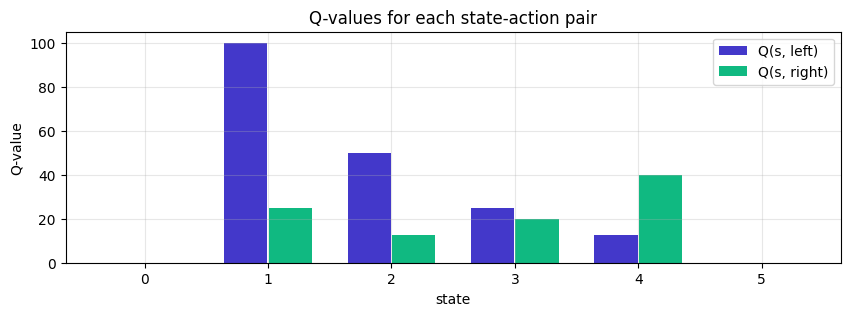

In [3]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(np.arange(N_STATES) - 0.18, Q[:, 0], width=0.35, color="#4338ca", label="Q(s, left)")
ax.bar(np.arange(N_STATES) + 0.18, Q[:, 1], width=0.35, color="#10b981", label="Q(s, right)")
ax.set_xticks(range(N_STATES))
ax.set_xlabel("state"); ax.set_ylabel("Q-value")
ax.set_title("Q-values for each state-action pair")
ax.legend(); ax.grid(alpha=0.3)
plt.show()


## ⭐ Stretch — discount factor sensitivity\n\nSweep gamma from 0.1 (impatient) to 0.9 (patient). Watch how the rover's policy at state 3 in particular changes — it's the closest 'tipping point' between the two rewards.\n\nIn real RL problems gamma matters a lot — too low and the agent is short-sighted (think a robot that grabs the nearest bad option instead of waiting for a better one). Too high and the agent is overly cautious about every step.

In [4]:
print(f"{'gamma':>6}  {'state 1':>8}  {'state 2':>8}  {'state 3':>8}  {'state 4':>8}")
for gamma_test in [0.1, 0.3, 0.5, 0.9]:
    Q_g = q_learn(gamma=gamma_test, seed=0)
    pol = ["left" if Q_g[s, 0] >= Q_g[s, 1] else "right" for s in [1, 2, 3, 4]]
    print(f"{gamma_test:>6}  {pol[0]:>8}  {pol[1]:>8}  {pol[2]:>8}  {pol[3]:>8}")
print()
print("With low gamma (impatient), state 4 still goes right (closest reward).")
print("With higher gamma (patient), more states are willing to walk further for the bigger 100 reward.")


 gamma   state 1   state 2   state 3   state 4
   0.1      left      left     right     right
   0.3      left      left     right     right


   0.5      left      left      left     right
   0.9      left      left      left      left

With low gamma (impatient), state 4 still goes right (closest reward).
With higher gamma (patient), more states are willing to walk further for the bigger 100 reward.
